# Introduction to PyTorch

In [ ]:
# PyTorch comes pre-installed with Google Colab

#importing pytorch and checking its version
import torch
print(torch.__version__)

2.11.0+cu128


In [ ]:
# Check for GPU availability
if torch.cuda.is_available():
  print("GPU is available")
else:
  print("GPU is not available")

# To run the code on GPU, go to Runtime > Change runtime type.
# Click T4GPU and click Okay.
# Rerun the cells, the output would say that GPU is available.

GPU is available


In [ ]:
# Check GPU Device Name
torch.cuda.get_device_name(0)

'Tesla T4'

## Creating a Tensor

In [ ]:
# 1. Direct creation from data
data = [[1, 2, 3], [4, 5, 6]]
tensor_a = torch.tensor(data)
print(tensor_a)

tensor([[1, 2, 3],
        [4, 5, 6]])


In [ ]:
# 2. Creation from shape
tensor_shape = (2, 3) # a 2 x 3 matrix dimensions(tensor)

tensor_b = torch.ones(tensor_shape)
tensor_c = torch.zeros(tensor_shape)
tensort_d = torch.rand(tensor_shape)

print("Tensor Object with Dimensions {} containing ones".format(tensor_shape))
print(tensor_b)

print("\nTensor Object with Dimensions {} containing zeros".format(tensor_shape))
print(tensor_c)

print("\nTensor Object with Dimensions {} containing random values".format(tensor_shape))
print(tensort_d)

Tensor Object with Dimensions (2, 3) containing ones
tensor([[1., 1., 1.],
        [1., 1., 1.]])

Tensor Object with Dimensions (2, 3) containing zeros
tensor([[0., 0., 0.],
        [0., 0., 0.]])

Tensor Object with Dimensions (2, 3) containing random values
tensor([[0.3453, 0.2293, 0.1061],
        [0.9590, 0.7468, 0.3224]])


This is how you initialize weights for your neural network model.

In [ ]:
# 3. Creation from another tensor
tensor_1 = torch.tensor([[2, 3, 4, 5], [1, 3, -5, 5]])

tensor_2 = torch.ones_like(tensor_1)
print("tensor_1: {}".format(tensor_1))
print("\ntensor_2: {}".format(tensor_2))
print("\ntensor_2 is created by copying the shape and type of tensor_1 and filling it ones.")

tensor_1: tensor([[ 2,  3,  4,  5],
        [ 1,  3, -5,  5]])

tensor_2: tensor([[1, 1, 1, 1],
        [1, 1, 1, 1]])

tensor_2 is created by copying the shape and type of tensor_1 and filling it ones.


Note: In place of `ones_like` function in the above code, if you use `rand_like`, the code will throw an error. The function `rand` generates random numbers between 0 and 1 which are of float type but `tensor_1` has values of integer type. Hence when passing `tensor_1` to `rand_like`, the code will throw an error.

## What's inside a Tensor?

Three critical attributes of a tensor:


1.   Shape: Tuple describing the dimensions of the tensor
2.   Data Type: Data type of the values in the tensor. By default, it is float32
3.   Device: Storage where tensor lives. It could be either CPU or CUDA (GPU)



In [ ]:
print(tensor_a)

print(f"Shape of tensor_a: {tensor_a.shape}")
print(f"Data type of tensor_a: {tensor_a.dtype}")
print(f"Device where tensor is stored: {tensor_a.device}")

tensor([[1, 2, 3],
        [4, 5, 6]])
Shape of tensor_a: torch.Size([2, 3])
Data type of tensor_a: torch.int64
Device where tensor is stored: cpu


Why is the default data type of a tensor is float?

It is because deep learning works by making tiny, continuous adjustments of weights. The parameters are adjusted in small steps, like from 3 to 3.001 or 3.002. If we go from 3 to 4, then the model might miss an optimal parameter in its training. Hence the default data type.

Basic thumb rule: weights and biases are always in float (float32) while data counts or categories are in integers.

## Autograd (Automatic Differentiation)

Autograd is PyTorch's in-built gradient calculator which can be activated by including the attribute

<div align='center'>

`requires_grad=True`

</div>

when creating a tensor. By doing so, we mean that it's a learnable parameter and it needs to be tracked for every single operation that happens to it.

In [ ]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])

w = torch.tensor([[7.0, 8.0, 9.0], [10.0, 11.0, 12.0]], requires_grad=True)

print(f"Does tensor x require gradient? {x.requires_grad}")
print(f"Does tensor w require gradient? {w.requires_grad}")

Does tensor x require gradient? False
Does tensor w require gradient? True


As we turn on this autograd, PyTorch starts to build a computation graph behind the screen. To walk you through an example, let us compute the following tensor operation:

<div align='center'>
$z = x \times y, \text{where } y = a + b$
</div>

Clearly, $a, b, x$ are independent parameters.

In [ ]:
# Three independent parameters
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(3.0, requires_grad=True)

print(a)
print(b)
print(x)

tensor(2., requires_grad=True)
tensor(1., requires_grad=True)
tensor(3., requires_grad=True)


In [ ]:
y = a + b # First operation
print(y)

tensor(3., grad_fn=<AddBackward0>)


In [ ]:
z = x * y # Second operation
print(z)

tensor(9., grad_fn=<MulBackward0>)


When printing the tensors `y` and `z`, we could see a new attribute called `grad_fn`. What is this new thing appearing? Remember when I said PyTorch builds a computation graph when activating the autograd system? When a tensor is created by an operation, it has this special attribute which tells us how that tensor is created.

For the tensor `z`, it is created by multiplying tensors `x` and `y`, indicated by `grad_fn=<MulBackward0>`. Similarly for tensor `y`, it is created by adding tensors `a` and `b`, indicated by `grad_fn=<AddBackward0>`. But for tensor `a`, the `grad_fn` is `None` since it's an independent parameter.

<div align='center'>

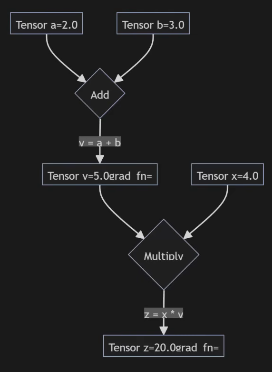

</div>

This computation graph helps PyTorch to remember how resulting tensors (in this example, `y` and `z`) are created and it also helps the autograd to find the gradient of the resulting tensors with respect to the parameters (in this example, `a` and `b`) by tracking down the operations backward.

So far, we created two parameters `a` and `b`. Then calculated a new tensor `y` by the result of addition of the parameters. Finally, we also calculated another new tensor `z` which is the product of a new parameter `x` and the resulting tensor `y`. This whole process constitutes what's called the forward pass.

In order to find the gradients
<div align='center'>

$\dfrac{dz}{da} \text{ and }\dfrac{dz}{db}$

</div>

we need to explicitly mention a new attribute called `backward()` that goes on to compute the gradients by chain rule of differentiation.

Remember:

<div align='center'>

$y = a + b, z = x * y$

</div>

where a, b, and x are parameters. Then

<div align='center'>

$\dfrac{dz}{da} = \dfrac{dz}{dy} . \dfrac{dy}{da}$

$\dfrac{dz}{db} = \dfrac{dz}{dy} . \dfrac{dy}{db}$

</div>

In [ ]:
# Recall parameters and resulting tensors
print("Parameters: \na = {}\nb = {}\nx = {}\n\nResulting Tensors: \ny = {}\nz = {}".format(a, b, x, y, z))

Parameters: 
a = 2.0
b = 1.0
x = 3.0

Resulting Tensors: 
y = 3.0
z = 9.0


In [ ]:
z.backward()

In [ ]:
a.grad

tensor(3.)

In [ ]:
b.grad

tensor(3.)

In the last three cells above, what we have outputted are the gradients which were computed upon calling `backward()` on the final resulting tensor `z`.

<div align='center'>

a.grad $ \rightarrow \dfrac{dz}{da} = \dfrac{dz}{dy}.\dfrac{dy}{da} = x . 1 = 3$

b.grad $ \rightarrow \dfrac{dz}{db} = \dfrac{dz}{dy}.\dfrac{dy}{db} = x . 1 = 3$


</div>

### Neural Network Gradient Calculation Example


1. Input: x | Output: y

In [ ]:
x = torch.tensor(8.5)
y = torch.tensor(0.0)

2. Initialize weight w and bias b

In [ ]:
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

3. Compute output (y_pred = sigmoid(z=wx+b))

In [ ]:
z = w*x + b
y_pred = torch.sigmoid(z)

4. Compute loss (binary cross entropy)

In [ ]:
from torch.nn import functional as F
loss = F.binary_cross_entropy(y_pred, y)
loss

tensor(8.5002, grad_fn=<BinaryCrossEntropyBackward0>)

5. Activate backward propagation

In [ ]:
loss.backward()

6. Checkout the gradients

In [ ]:
w.grad # gradient of loss with respect to weight

tensor(8.4983)

In [ ]:
b.grad # gradient of loss with respect to bias

tensor(0.9998)

### Clearing Gradients

Run Lines 1-4 once and Lines 2-4 again.

In [ ]:
x = torch.tensor(2.0, requires_grad=True) # Line 1

In [ ]:
y = x**2 # Line 2

In [ ]:
y.backward() # Line 3

In [ ]:
x.grad # Line 4

tensor(4.)

After the first forward and backward pass, the gradient was found to be 4. But after the second forward and backward pass, the gradient was found to be 8 and not 4! This is because gradients gets accumulated as the propagation repeats. In a neural network, the propagation repeats and we wouldn't want the gradient to be accumulated for every forward and backward pass together. In order to avoid that, we need to clear the previous gradient and this is achieved by adding one more line `x.grad.zero_()`. Now run Lines 1-5 and 2-4 and check out the difference

In [ ]:
x.grad.zero_() # Line 5

tensor(0.)

### Disable Gradient Tracking

During training, we are interested in finding gradients and hence we enable `requires_grad` and backward propagation. But for testing or making predictions, there is no necessity to calculate the gradients since we're only making forward pass and gradients are not of our interest. So it is wise to stop computing gradients as it helps in faster computation of the predictions and less memory usage. There are three ways to disable gradient tracking.

Option 1: x.requires_grad_(False)

In [ ]:
x1 = torch.tensor(2.0, requires_grad=True)

In [ ]:
y1 = x1**2

In [ ]:
x1

tensor(2., requires_grad=True)

In [ ]:
y1

tensor(4., grad_fn=<PowBackward0>)

In [ ]:
y1.backward()

In [ ]:
x1.grad

tensor(4.)

In [ ]:
x1.requires_grad_(False) # diables gradient tracking

tensor(2.)

In [ ]:
y1.backward()

# Backward propagation cannot be performed
# since we disabled gradient tracking for x1.

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

Option 2: detach()

In [ ]:
x2 = torch.tensor(3.0, requires_grad=True)
x2

tensor(3., requires_grad=True)

In [ ]:
z = x2.detach() # z retains x2 tensor but does not track any operation
z

tensor(3.)

In [ ]:
y2 = x2**2 # creating a new tensor from x2
y2

tensor(9., grad_fn=<PowBackward0>)

In [ ]:
y2.backward()
# y2 can back track the operation
# because x2 is being tracked for every operation
# hence gradient can be obtained as shown in the next cell

In [ ]:
x2.grad

tensor(6.)

In [ ]:
y3 = z**2 # creating a new tensor from z
y3

tensor(9.)

In [ ]:
y3.backward()
# y3 cannot back track the operation
# because z is a tensor which is not tracked
# hence gradient cannot be obtained

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

Option 3: torch.no_grad()

In [ ]:
x3 = torch.tensor(3.0, requires_grad=True)
x3

tensor(4., requires_grad=True)

In [ ]:
with torch.no_grad():
  # with torch.no_grad(),
  # the following block of statements does not track gradients
  y3 = x**2

In [ ]:
y3

tensor(4.)

In [ ]:
y3.backward()

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn